In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import kagglehub
from kagglehub import KaggleDatasetAdapter

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [67]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/netflix-shows",
    "netflix_titles.csv"
)

print("Dataset Shape:", df.shape)
df.head()

/tmp/ipykernel_435/1775654435.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [68]:
df_clean = df.copy()

df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")

df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].mode()[0])
df_clean["duration"] = df_clean["duration"].fillna("Unknown")

df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], errors="coerce")

df_clean = df_clean.dropna(subset=["date_added"])
df_clean = df_clean.drop_duplicates()

df_clean.reset_index(drop=True, inplace=True)

print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (8709, 12)


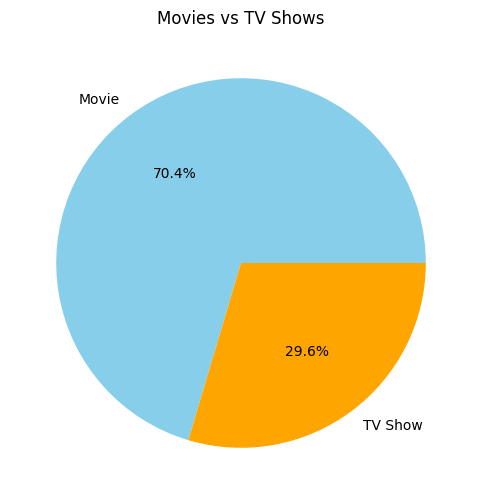

In [69]:
plt.figure(figsize=(6,6))

df_clean["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","orange"]
)

plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

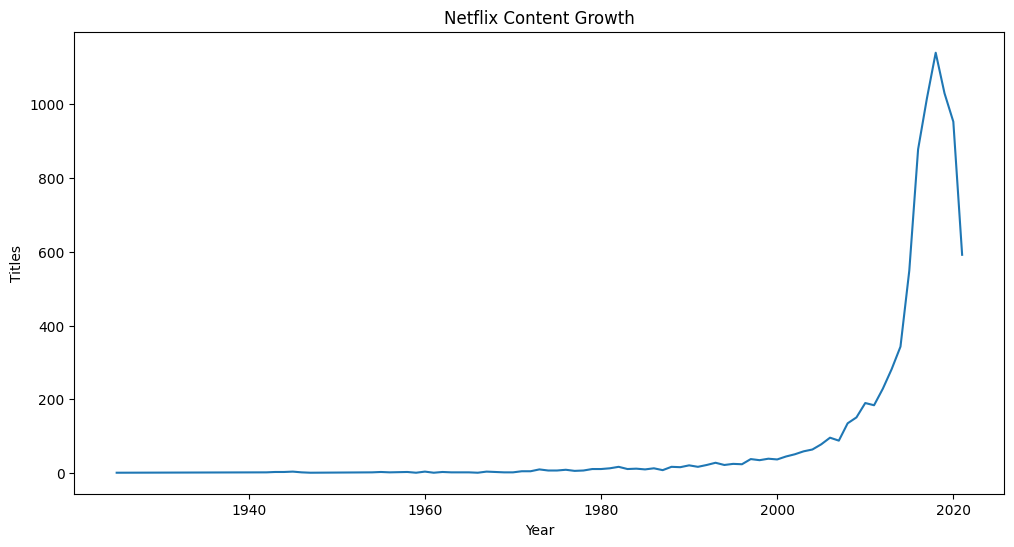

In [70]:
year_counts = df_clean["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Netflix Content Growth")
plt.xlabel("Year")
plt.ylabel("Titles")

plt.show()

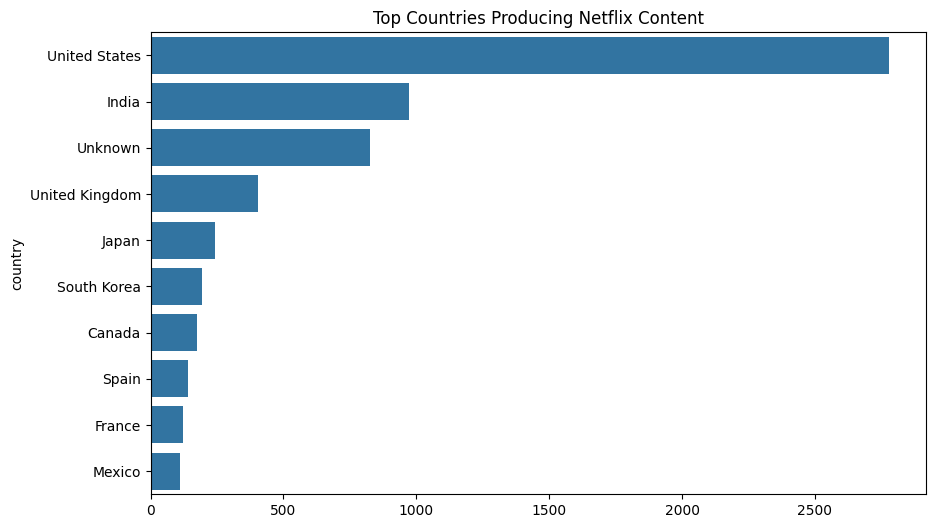

In [71]:
top_countries = df_clean["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries Producing Netflix Content")

plt.show()

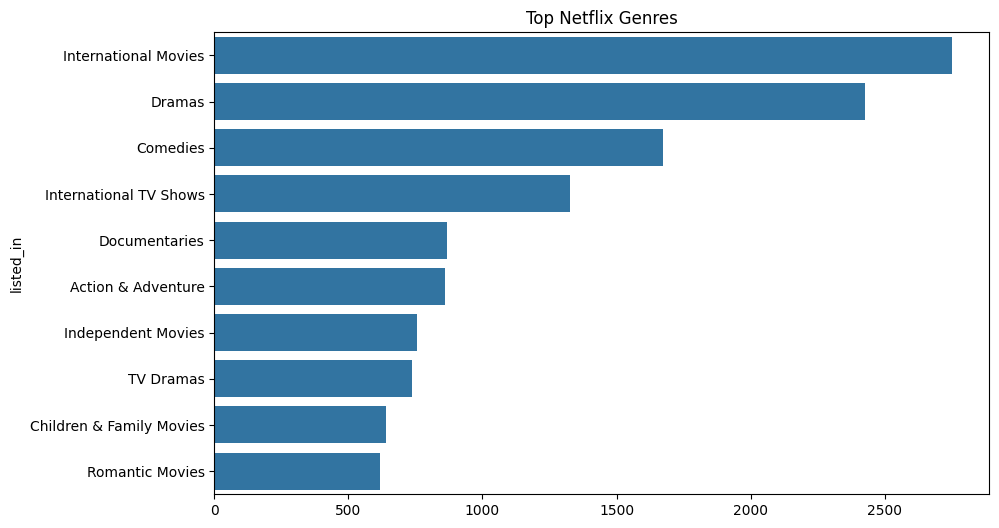

In [72]:
genres = df_clean["listed_in"].str.split(", ").explode()

plt.figure(figsize=(10,6))

sns.barplot(
    x=genres.value_counts().head(10).values,
    y=genres.value_counts().head(10).index
)

plt.title("Top Netflix Genres")

plt.show()

In [73]:
stop_words = set(stopwords.words("english"))

In [75]:
df_clean["short_description"] = df_clean["description"].apply(
    lambda x: " ".join(x.split()[:40])
)

In [76]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^\w\s]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [77]:
df_clean["desc_clean"] = df_clean["short_description"].apply(clean_text)
df_clean["cast_clean"] = df_clean["cast"].apply(clean_text)
df_clean["country_clean"] = df_clean["country"].apply(clean_text)
df_clean["director_clean"] = df_clean["director"].apply(clean_text)

In [78]:
generic_genres = [
    "International TV Shows",
    "TV Shows",
    "Movies"
]

def clean_genre(genre):

    genres = genre.split(", ")

    genres = [g for g in genres if g not in generic_genres]

    return " ".join(genres)

df_clean["genre_clean"] = df_clean["listed_in"].apply(clean_genre)

In [79]:
df_clean["combined_features"] = (

    df_clean["genre_clean"] + " " +
    df_clean["genre_clean"] + " " +
    df_clean["genre_clean"] + " " +

    df_clean["desc_clean"] + " " +
    df_clean["desc_clean"] + " " +

    df_clean["cast_clean"] + " " +
    df_clean["country_clean"] + " " +
    df_clean["director_clean"]

)

In [80]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=7000,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(df_clean["combined_features"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (8709, 7000)


In [83]:
knn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=10
)

knn_model.fit(tfidf_matrix)

print("KNN Model Ready")

KNN Model Ready


In [84]:
def recommend(title, n_recommendations=5):

    title = title.lower()

    titles = df_clean["title"].str.lower()

    if title not in titles.values:
        print("Title not found in dataset.")
        return

    idx = titles[titles == title].index[0]

    movie_type = df_clean.iloc[idx]["type"]

    distances, indices = knn_model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=15
    )

    distances = distances.flatten()[1:]
    indices = indices.flatten()[1:]

    results = df_clean.iloc[indices].copy()

    # keep only same type (movie or TV show)
    results = results[results["type"] == movie_type]

    results = results[
        ["title","listed_in","country","release_year"]
    ]

    results["similarity_score"] = 1 - distances[:len(results)]

    return results.head(n_recommendations)

In [85]:
recommend("kota factory")

,title,listed_in,country,release_year,similarity_score
6418,Castle of Stars,"International TV Shows, Romantic TV Shows, TV ...",Unknown,2015,0.439954
4570,Hot Date,"Romantic TV Shows, TV Comedies",United States,2018,0.424899
5703,Refresh Man,"International TV Shows, Romantic TV Shows, TV ...",Taiwan,2016,0.409272
7743,Queen of No Marriage,"International TV Shows, Romantic TV Shows, TV ...",Taiwan,2009,0.403991
707,Let's Eat,"International TV Shows, Romantic TV Shows, TV ...",Unknown,2021,0.402866
